<a href="https://colab.research.google.com/github/Medini-27/ANN-mini_project-/blob/main/1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class Perceptron:
    def __init__(self, lr=0.01, epochs=1000):
        self.lr = lr
        self.epochs = epochs
        self.weights = None
        self.bias = None

    def activation(self, x):
        return np.where(x >= 0, 1, 0)

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for epoch in range(self.epochs):
            for i in range(n_samples):
                linear_output = np.dot(X[i], self.weights) + self.bias
                y_pred = self.activation(linear_output)

                update = self.lr * (y[i] - y_pred)
                self.weights += update * X[i]
                self.bias += update

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return self.activation(linear_output)



AND Predictions: [0 0 0 1]
OR Predictions: [0 1 1 1]
Blob Dataset Accuracy: 1.0


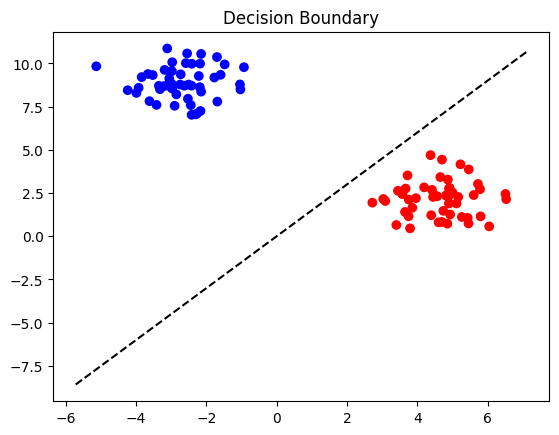


Performance Analysis:
Weights: [ 0.08711302 -0.05801655]
Bias: 0.0

Challenges:
- Perceptron only works for linearly separable data
- Fails on XOR problem
- Sensitive to learning rate
- May not converge if data is not separable
- Binary classification only


In [ ]:
X_and = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y_and = np.array([0, 0, 0, 1])

model = Perceptron(lr=0.1, epochs=10)
model.fit(X_and, y_and)

predictions_and = model.predict(X_and)
print("AND Predictions:", predictions_and)

X_or = X_and

y_or = np.array([0, 1, 1, 1])

model_or = Perceptron(lr=0.1, epochs=10)
model_or.fit(X_or, y_or)

predictions_or = model_or.predict(X_or)
print("OR Predictions:", predictions_or)

# -----------------------------
# Dataset: Linearly Separable Points
# -----------------------------
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=100, centers=2, random_state=42)

y = np.where(y == 0, 0, 1)

model_blob = Perceptron(lr=0.01, epochs=100)
model_blob.fit(X, y)

predictions_blob = model_blob.predict(X)
accuracy = np.mean(predictions_blob == y)
print("Blob Dataset Accuracy:", accuracy)

# -----------------------------
# Visualization
# -----------------------------

def plot_decision_boundary(X, y, model):
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr')
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    x_vals = np.linspace(xlim[0], xlim[1], 100)
    y_vals = -(model.weights[0] * x_vals + model.bias) / model.weights[1]

    plt.plot(x_vals, y_vals, 'k--')
    plt.title("Decision Boundary")
    plt.show()

plot_decision_boundary(X, y, model_blob)

# -----------------------------
# Performance Analysis
# -----------------------------
print("\nPerformance Analysis:")
print("Weights:", model_blob.weights)
print("Bias:", model_blob.bias)

# -----------------------------
# Challenges Encountered
# -----------------------------
challenges = [
    "Perceptron only works for linearly separable data",
    "Fails on XOR problem",
    "Sensitive to learning rate",
    "May not converge if data is not separable",
    "Binary classification only"
]

print("\nChallenges:")
for c in challenges:
    print("-", c)
